# 06 — NDTI plume segmentation: parameter tuning

Step-by-step version of `06_isegprob_ndti.py` for tuning on a single scene before the batch run.
Every step matches the script exactly, and all spatial settings are in **meters** so they carry over
to SAR or other imagery with a different pixel size.

1. Load NDTI
2. Smooth (valid-data-weighted mean)
3. Threshold (NDTI ≥ `threshold`)
4. Morphological cleanup
5. Distance to nearest outfall
6. Clusters: keep those that come within `max_distance_m` of an outfall
7. Final mask
8. Compare thresholds side by side
9. Copy parameters into the script / run the batch

Edit the two parameter cells below, then run all.

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, distance_transform_edt, label, minimum
from skimage.morphology import (
    binary_opening, binary_closing, binary_dilation,
    remove_small_objects, remove_small_holes, disk
)
import geopandas as gpd
import rasterio
from rasterio.features import rasterize

plt.rcParams['figure.figsize'] = (9, 7)

## Inputs

In [2]:
input_dir = Path('/home/jovyan/s2/04_NDTI')          # folder of *_NDTI.tif (step 05 writes 06_NDTI)
image_path = input_dir / 'mosaic_20220103T183749_NDTI.tif'   # scene to tune on
outfall_shapefile = '/home/jovyan/s2/shapefiles/Outflow.shp'
script_path = Path('06_isegprob_ndti.py')        # used in the batch section at the end

## Parameters
These are the only knobs. Spatial values are meters / m² and get converted to pixels from the scene's own pixel size.
The starting values match what the earlier test notebook used on your ~16.4 m mosaics.

In [3]:
threshold = 0.07             # NDTI at or above this counts as turbid water
max_distance_m = 1300.0        # keep clusters that come within this distance of an outfall

smooth_window_m = 49.0         # low-pass filter window width
open_radius_m = 33.0           # opening: removes specks/thin features
close_radius_m = 49.0          # closing: bridges small gaps
min_hole_area_m2 = 80300.0     # fill holes smaller than this (~8 ha)
min_object_area_m2 = 26800.0   # drop patches smaller than this (~2.7 ha)
dilate_radius_m = 33.0         # final dilation buffer

In [4]:
def disk_px(radius_m, px_m):
    """Structuring element whose radius is radius_m meters (at least 1 pixel)."""
    return disk(max(1, round(radius_m / px_m)))

def area_px(area_m2, px_x, px_y):
    """Convert an area in square meters to a pixel count (at least 1 pixel)."""
    return max(1, round(area_m2 / (px_x * px_y)))

## Step 1 — Load the NDTI raster

shape: (3053, 1901), crs: EPSG:32611
pixel size: 16.36 x 16.36 m
NDTI range (ignoring NaN): -inf to 61.000


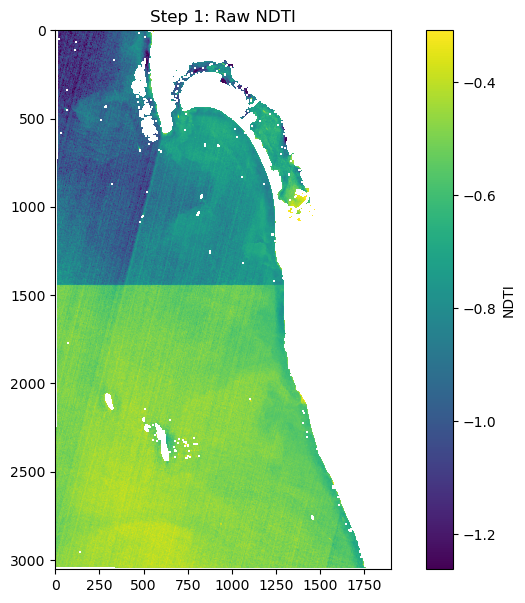

In [5]:
with rasterio.open(image_path) as src:
    img = src.read(1).astype(np.float32)
    profile = src.profile
    transform = src.transform
    crs = src.crs
    h, w = src.height, src.width
    bounds = src.bounds

px_x, px_y = abs(transform.a), abs(transform.e)
if crs.is_geographic:
    mid_lat = (bounds.bottom + bounds.top) / 2.0
    px_x *= 111320 * math.cos(math.radians(mid_lat))
    px_y *= 110540
px_mean = (px_x + px_y) / 2.0

print(f'shape: {img.shape}, crs: {crs}')
print(f'pixel size: {px_x:.2f} x {px_y:.2f} m')
print(f'NDTI range (ignoring NaN): {np.nanmin(img):.3f} to {np.nanmax(img):.3f}')

clims = np.nanpercentile(img, [2, 98])
fig, ax = plt.subplots()
im = ax.imshow(img, cmap='viridis', vmin=clims[0], vmax=clims[1])
ax.set_title('Step 1: Raw NDTI')
plt.colorbar(im, ax=ax, label='NDTI')
plt.show()

## What the meter settings mean in pixels for this scene
Rounding matters at coarse resolution: e.g. a 20 m radius on a 16 m pixel rounds to 1 px.

In [ ]:
win = max(1, round(smooth_window_m / px_mean))
win += (win % 2 == 0)   # keep odd so the window stays centered

pd.DataFrame([
    ('smoothing window', f'{smooth_window_m:g} m', f'{win} px'),
    ('opening radius',   f'{open_radius_m:g} m',   f'{max(1, round(open_radius_m / px_mean))} px'),
    ('closing radius',   f'{close_radius_m:g} m',  f'{max(1, round(close_radius_m / px_mean))} px'),
    ('min hole area',    f'{min_hole_area_m2/1e4:g} ha',   f'{area_px(min_hole_area_m2, px_x, px_y)} px'),
    ('min object area',  f'{min_object_area_m2/1e4:g} ha', f'{area_px(min_object_area_m2, px_x, px_y)} px'),
    ('dilation radius',  f'{dilate_radius_m:g} m', f'{max(1, round(dilate_radius_m / px_mean))} px'),
], columns=['setting', 'value', 'in pixels'])

## Step 2 — Low-pass filter (valid-data weighted)

In [ ]:
valid = (~np.isnan(img)).astype(np.float32)
filled = np.nan_to_num(img, nan=0.0)
num = uniform_filter(filled, size=win, mode='nearest')
den = uniform_filter(valid, size=win, mode='nearest')
smooth = np.full_like(img, np.nan, dtype=np.float32)
has_data = den > 0
smooth[has_data] = num[has_data] / den[has_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img, cmap='viridis', vmin=clims[0], vmax=clims[1]); axes[0].set_title('Before smoothing')
axes[1].imshow(smooth, cmap='viridis', vmin=clims[0], vmax=clims[1]); axes[1].set_title(f'Step 2: After smoothing ({win}x{win} px)')
plt.tight_layout(); plt.show()

## Step 3 — Threshold
Check the cut against the histogram of smoothed NDTI over water.

In [ ]:
vals = smooth[~np.isnan(smooth)]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(vals, bins=200, color='steelblue')
ax.axvline(threshold, color='r', linestyle='--', label=f'threshold = {threshold}')
ax.set_xlabel('NDTI (smoothed)'); ax.set_ylabel('# pixels'); ax.set_title('Smoothed NDTI distribution')
ax.legend(); plt.show()

signal = (smooth >= threshold) & ~np.isnan(smooth)
print(f'{signal.sum():,} pixels ({signal.sum() * px_x * px_y / 1e6:.2f} km²) at or above {threshold}')

## Step 4 — Morphological cleanup

In [ ]:
opened = binary_opening(signal, disk_px(open_radius_m, px_mean))
closed = binary_closing(opened, disk_px(close_radius_m, px_mean))
filled_holes = remove_small_holes(closed, area_threshold=area_px(min_hole_area_m2, px_x, px_y))
no_small = remove_small_objects(filled_holes, min_size=area_px(min_object_area_m2, px_x, px_y))
mask = binary_dilation(no_small, disk_px(dilate_radius_m, px_mean))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (title, arr) in zip(axes.ravel(), [
        ('1. Threshold', signal), ('2. Opened', opened), ('3. Closed', closed),
        ('4. Holes filled', filled_holes), ('5. Small objects removed', no_small),
        ('6. Dilated (final)', mask)]):
    ax.imshow(arr, cmap='gray', interpolation='nearest')
    ax.set_title(f'{title}\n{arr.sum():,} px'); ax.axis('off')
plt.tight_layout(); plt.show()

## Step 5 — Distance to nearest outfall (meters)

In [ ]:
outfalls = gpd.read_file(outfall_shapefile).to_crs(crs)
outfall_r = rasterize([(g, 1) for g in outfalls.geometry], out_shape=(h, w),
                      transform=transform, fill=0, dtype='uint8')
assert outfall_r.any(), 'No outfall falls inside this scene - the script would skip it.'
dist_m = distance_transform_edt(outfall_r == 0, sampling=(px_y, px_x)).astype(np.float32)
ys, xs = np.where(outfall_r == 1)

print(f'{len(outfalls)} outfall point(s); distance range 0 to {dist_m.max()/1000:.1f} km')
fig, ax = plt.subplots()
im = ax.imshow(dist_m / 1000, cmap='magma_r')
ax.contour(dist_m, levels=[max_distance_m], colors='cyan', linewidths=1.2)
ax.scatter(xs, ys, c='cyan', s=20, edgecolor='k')
ax.set_title(f'Step 5: Distance to outfall (cyan = {max_distance_m:.0f} m cutoff)')
plt.colorbar(im, ax=ax, label='km'); plt.show()

## Step 6 — Clusters and the distance cutoff
Each cluster gets its closest distance to an outfall; it's kept if that is ≤ `max_distance_m`.
The histogram shows where your cutoff falls relative to the clusters in this scene.

In [ ]:
labels, n_clusters = label(mask)
if n_clusters:
    ids = np.arange(1, n_clusters + 1)
    min_d = np.asarray(minimum(dist_m, labels, index=ids))
    sizes = np.bincount(labels.ravel(), minlength=n_clusters + 1)[1:]
    clusters = pd.DataFrame({
        'cluster': ids,
        'area_ha': sizes * px_x * px_y / 1e4,
        'closest_to_outfall_m': min_d.round(0),
        'kept': min_d <= max_distance_m,
    }).sort_values('closest_to_outfall_m').reset_index(drop=True)
    accepted = ids[min_d <= max_distance_m]
else:
    clusters = pd.DataFrame(columns=['cluster', 'area_ha', 'closest_to_outfall_m', 'kept'])
    accepted = np.array([], dtype=int)

print(f'{n_clusters} cluster(s); {len(accepted)} within {max_distance_m:.0f} m of an outfall')
if n_clusters:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.hist(clusters['closest_to_outfall_m'] / 1000, bins=40, color='steelblue')
    ax.axvline(max_distance_m / 1000, color='r', linestyle='--', label='cutoff')
    ax.set_xlabel('cluster closest distance to outfall (km)'); ax.set_ylabel('# clusters'); ax.legend()
    plt.show()
clusters.head(20)

## Step 7 — Final mask

In [ ]:
mask_selected = np.isin(labels, accepted)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(labels, cmap='nipy_spectral', interpolation='nearest')
axes[0].set_title(f'Clusters (n={n_clusters}, {len(accepted)} kept)')
axes[1].imshow(img, cmap='gray', vmin=clims[0], vmax=clims[1])
axes[1].imshow(np.ma.masked_where(~mask_selected, mask_selected), cmap='autumn', alpha=0.6, interpolation='nearest')
axes[1].contour(dist_m, levels=[max_distance_m], colors='cyan', linewidths=1.2)
axes[1].scatter(xs, ys, c='cyan', s=20, edgecolor='k')
axes[1].set_title(f'Final plume mask: {mask_selected.sum():,} px ({mask_selected.sum() * px_x * px_y / 1e6:.2f} km²)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## Step 8 — Compare thresholds side by side
Runs steps 3–7 for several thresholds with everything else fixed, so you can see how sensitive the final mask is.

In [ ]:
thresholds_to_try = [0.05, 0.0675, 0.075, 0.09, 0.11]

def final_mask_for(th):
    sig = (smooth >= th) & ~np.isnan(smooth)
    m = binary_opening(sig, disk_px(open_radius_m, px_mean))
    m = binary_closing(m, disk_px(close_radius_m, px_mean))
    m = remove_small_holes(m, area_threshold=area_px(min_hole_area_m2, px_x, px_y))
    m = remove_small_objects(m, min_size=area_px(min_object_area_m2, px_x, px_y))
    m = binary_dilation(m, disk_px(dilate_radius_m, px_mean))
    lab, n = label(m)
    if n == 0:
        return np.zeros_like(m)
    ids = np.arange(1, n + 1)
    d = np.asarray(minimum(dist_m, lab, index=ids))
    return np.isin(lab, ids[d <= max_distance_m])

fig, axes = plt.subplots(1, len(thresholds_to_try), figsize=(4 * len(thresholds_to_try), 5))
for ax, th in zip(np.atleast_1d(axes), thresholds_to_try):
    fm = final_mask_for(th)
    ax.imshow(img, cmap='gray', vmin=clims[0], vmax=clims[1])
    ax.imshow(np.ma.masked_where(~fm, fm), cmap='autumn', alpha=0.6, interpolation='nearest')
    ax.scatter(xs, ys, c='cyan', s=12, edgecolor='k')
    ax.set_title(f'NDTI ≥ {th}\n{fm.sum() * px_x * px_y / 1e6:.2f} km²'); ax.axis('off')
plt.tight_layout(); plt.show()

## Step 9 — Use the tuned values

**Option A:** copy the printed block into the parameter section of `06_isegprob_ndti.py`.

**Option B:** run the batch from here. This imports the script, applies the parameters above,
and writes the masks, distance maps and QC PNGs exactly as the script would.

In [ ]:
print(f'''threshold = {threshold}
max_distance_m = {max_distance_m}

smooth_window_m = {smooth_window_m}
open_radius_m = {open_radius_m}
close_radius_m = {close_radius_m}
min_hole_area_m2 = {min_hole_area_m2}
min_object_area_m2 = {min_object_area_m2}
dilate_radius_m = {dilate_radius_m}''')

In [ ]:
run_batch = False                                   # set True when you're happy with the parameters
batch_output_dir = Path('/home/jovyan/s2/07_NDTI_isegprob')

if run_batch:
    import importlib.util
    spec = importlib.util.spec_from_file_location('isegprob', script_path)
    isegprob = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(isegprob)

    for name in ['threshold', 'max_distance_m', 'smooth_window_m', 'open_radius_m',
                 'close_radius_m', 'min_hole_area_m2', 'min_object_area_m2', 'dilate_radius_m',
                 'outfall_shapefile', 'input_dir']:
        setattr(isegprob, name, globals()[name])
    isegprob.output_dir = batch_output_dir
    isegprob.qc_dir = batch_output_dir / 'qc_pngs'

    isegprob.main()